In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_heatmap(df: pd.DataFrame,
                 title: str,
                 outpath: Path,
                 vmin=0.5,
                 vmax=1.0,
                 annotate=True):
    """
    Pretty heatmap with:
    - white text on dark cells
    - black text on light cells
    - rotated x labels
    """

    outpath = Path(outpath)

    # Copy cmap + set NaN color
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="#d3d3d3")  # light gray for missing

    data = df.values.astype(float)
    masked = np.ma.masked_invalid(data)

    # Normalizer for checking luminance
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Figure size proportional to matrix size
    fig_w = max(9, 0.55 * df.shape[1] + 3)
    fig_h = max(4, 0.5 * df.shape[0] + 2.5)

    plt.figure(figsize=(fig_w, fig_h))
    ax = plt.gca()

    im = ax.imshow(
        masked,
        aspect="auto",
        interpolation="none",   # no smoothing → fewer seams
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,        # important for PDF hairlines
    )

    # Remove outer frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(df.shape[0]))
    ax.set_yticklabels(df.index)

    # no minor gridlines
    ax.tick_params(which="both", length=0)

    # Colorbar
    cb = plt.colorbar(im)
    cb.set_label(title, rotation=270, labelpad=14)

    # Annotations
    if annotate:
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                val = df.iat[i, j]
                if not np.isnan(val):

                    rgba = cmap(norm(val))
                    r, g, b, _ = rgba

                    # luminance decides text color
                    luminance = 0.299*r + 0.587*g + 0.114*b
                    text_color = "white" if luminance < 0.5 else "black"

                    ax.text(
                        j, i, f"{val:.3f}",
                        ha="center", va="center",
                        fontsize=8, color=text_color
                    )

    plt.title(title)
    plt.tight_layout()

    # Save PDF
    outpath.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(outpath, dpi=300)
    plt.show()
    plt.close()


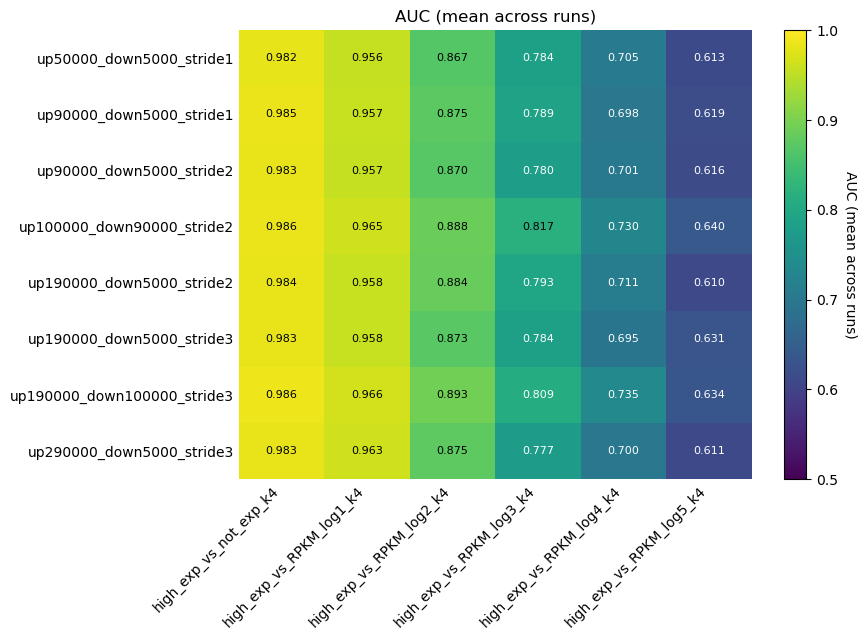

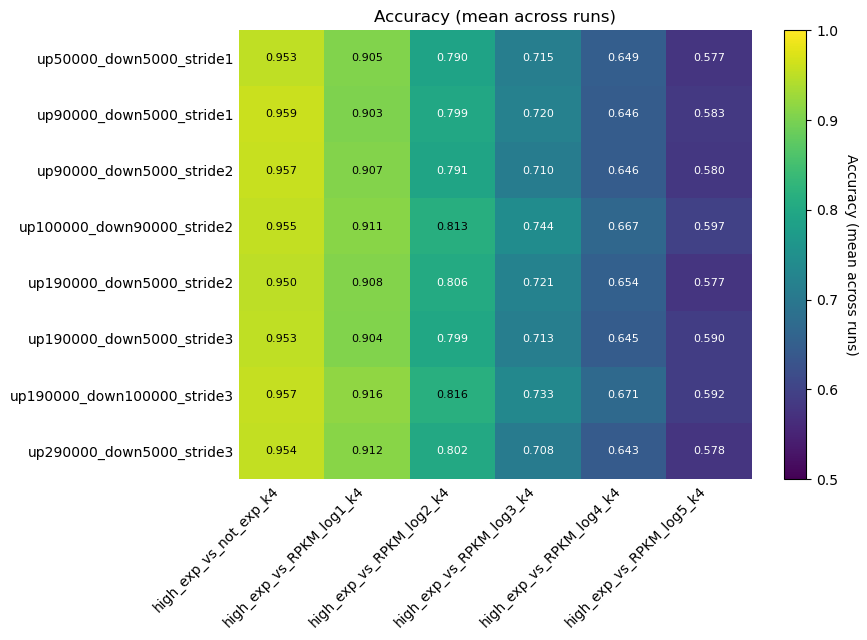

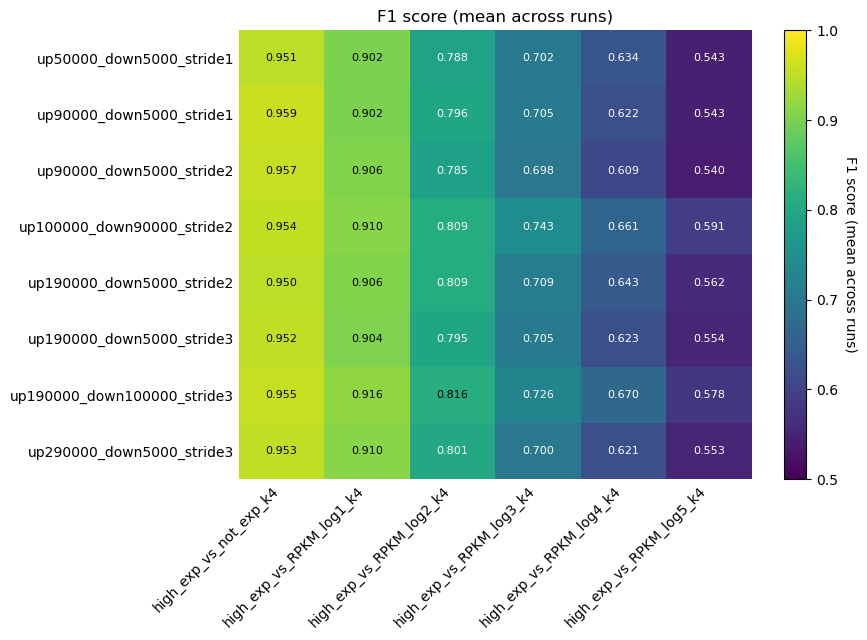

In [17]:
base_dir = Path("../revision_temp/finetune_results_logscale_train30000_dev6000_notomitO_finetunedebug/pdf")

accuracy_csv = base_dir / "heatmap_accuracy.csv"
f1_csv       = base_dir / "heatmap_f1_score.csv"
auc_csv      = base_dir / "heatmap_auc.csv"

df_acc = pd.read_csv(accuracy_csv, index_col=0)
df_f1  = pd.read_csv(f1_csv, index_col=0)
df_auc = pd.read_csv(auc_csv, index_col=0)

out_acc = "./Revision_code/Fig3b/heatmap_accuracy_styled.pdf"
out_f1  = "./Revision_code/Fig3b/heatmap_f1_score_styled.pdf"
out_auc = "./Revision_code/Fig3b/heatmap_auc_styled.pdf"

plot_heatmap(df_auc, "AUC (mean across runs)", out_auc)
plot_heatmap(df_acc, "Accuracy (mean across runs)", out_acc)
plot_heatmap(df_f1,  "F1 score (mean across runs)", out_f1)
